In [3]:
import numpy as np
import h5py
#from skimage import io
import matplotlib.pylab as plt
import glob
from tqdm import trange

# Examine simulated XRF and XRT images

In [18]:
import h5py
import numpy as np

data_path = '/mnt/micdata3/XRF_tomography/XRF_torch_2/data/sim_spheres'
XRF_data_file = 'sim_xrf_sa.h5'               
XRT_data_file = 'sim_xrt_sa.h5'

XRF_data_handle = h5py.File(os.path.join(data_path, XRF_data_file), 'r')
XRT_data_handle = h5py.File(os.path.join(data_path, XRT_data_file), 'r')
xrf_data = XRF_data_handle['exchange/data'][:]
xrt_data = XRT_data_handle['exchange/data'][:]
element_lines = XRF_data_handle['exchange/elements'][:]

print(f'xrt_data.shape: {xrt_data.shape}')
print(f'xrf_data.shape: {xrf_data.shape}')
print(f'element_lines: {element_lines}')
XRF_data_handle.close()    
XRT_data_handle.close()    


xrt_data.shape: (4, 100, 100)
xrf_data.shape: (2, 100, 100)
element_lines: [b'Cu' b'Ca']


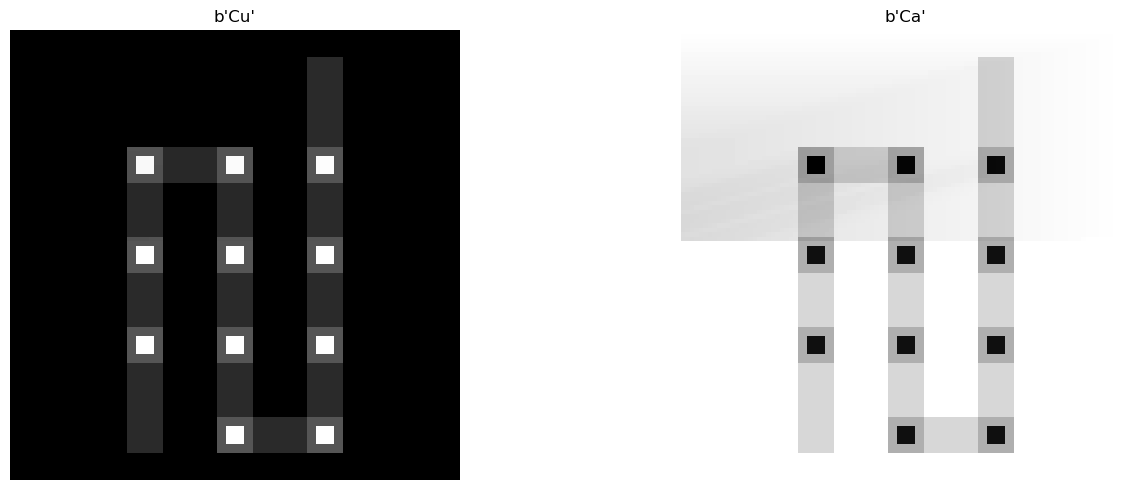

In [19]:
element_lines_roi = np.array([['Cu', 'K'], ['Ca', 'K']])

fig, axes = plt.subplots(1, xrf_data.shape[0], figsize=(15, 5))  # Create a subplot for each image
for i in range(xrf_data.shape[0]):
    axes[i].imshow(xrf_data[i, :, :], cmap='gray')  # Plot each image
    #axes[i].set_title(f'{element_lines_roi[i][0]} - {element_lines_roi[i][1]}')  # Set title for each subplot using element_lines_roi
    axes[i].set_title(f'{element_lines[i]}')  # Set title for each subplot using element_lines_roi
    
    axes[i].axis('off')  # Hide axes
plt.tight_layout()  # Adjust layout
plt.show()  # Display the plot

#plt.imshow(xrf_data[4,:,:], cmap='gray')  # 'cmap' defines the color map, 'gray' for grayscale
#plt.colorbar()  # Add colorbar to the figure
#plt.show()

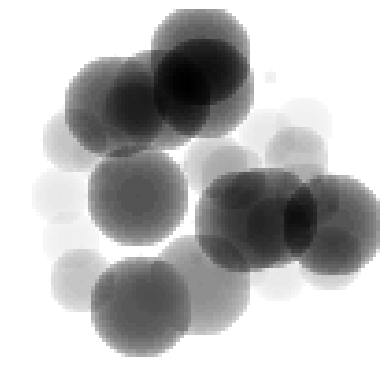

In [16]:
plt.imshow(xrt_data[-1,:,:], cmap='gray')  # 'cmap' defines the color map, 'gray' for grayscale
#plt.colorbar()  # Add colorbar to the figure
plt.axis('off')  # Remove the axis
plt.show()

# Check simulated test objects from Pats

In [58]:
import h5py
import numpy as np

# Path to the H5 file
file_path = '/home/beams/USER2IDD/xrf_tomo/XRF_torch/data/sim_spheres/xrf_array_data.h5'

# Open the H5 file
with h5py.File(file_path, 'r') as f:
    # Print the structure of the file
    print("File structure:")
    f.visit(lambda name: print(name))
    xrf_array =  f['xrf_array'][:]
    print(xrf_array.shape)

# only choose the 1st element
#xrf_array = xrf_array[0:3,:,:,:]
#print(xrf_array.shape)

# Save the XRF data to a new npy file
output_file_path = './data/sim_spheres/xrf_array_data.npy'
np.save(output_file_path, xrf_array)  # Save the XRF data as a numpy array


File structure:
xrf_array
(4, 100, 100, 100)


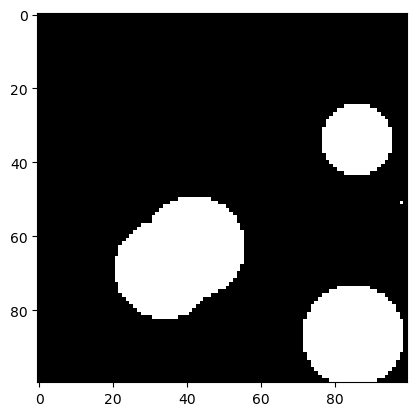

0.0


In [17]:
plt.imshow(xrf_array[3,60,:,:], cmap='gray')  # 'cmap' defines the color map, 'gray' for grayscale
plt.show()
print(xrf_array[2,60,50,50])

# Check simulated test objects used in Panpan's paper

In [4]:
import numpy as np


X = np.load('/mnt/micdata3/XRF_tomography/simulation/copper_structure/copper_structure_0227.npy')
print(f'Test objects size:{X.shape}')


Test objects size:(2, 100, 100, 100)


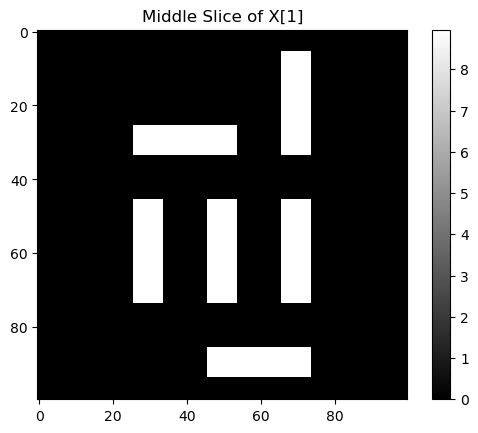

In [17]:
middle_slice = X[0, :, :, 60]  # Get the middle slice in the third dimension
plt.imshow(middle_slice, cmap='gray')  # Display the middle slice
plt.title('Middle Slice of X[1]')
plt.colorbar()
plt.show()


In [38]:
import h5py
import numpy as np

data_path = './data/Cabead_adjusted1_ds4'
f_XRF_data = 'cabead_xrf-fits'               
f_XRT_data = 'cabead_scalers'
XRF_data_handle = h5py.File(os.path.join(data_path, f_XRF_data), 'r')
XRT_data_handle = h5py.File(os.path.join(data_path, f_XRT_data), 'r')
xrf_data = XRF_data_handle['exchange/data']
xrt_data = XRT_data_handle['exchange/data']
print(xrf_data)
print(xrt_data)
channel_names = XRF_data_handle['exchange/elements']
print(channel_names[:])

<HDF5 dataset "data": shape (23, 181, 32, 124), type "<f4">
<HDF5 dataset "data": shape (24, 181, 32, 124), type "<f4">
[b'Al' b'Si' b'Cl' b'Ar' b'K' b'Ca' b'Ti' b'Cr' b'Mn' b'Fe' b'Co' b'Ni'
 b'Cu' b'Zn' b'Ba_L' b'Total_Fluorescence_Yield' b'Si_Si' b'Cl_Cl'
 b'COHERENT_SCT_AMPLITUDE' b'COMPTON_AMPLITUDE' b'Num_Iter'
 b'Fit_Residual' b'Sum_Elastic_Inelastic']


In [24]:
theta_ls_h5path = 'exchange/theta'
theta_ls = XRF_data_handle[theta_ls_h5path][...] * np.pi / 180  #unit: rad #cpu
n_theta = len(theta_ls)
print(theta_ls.shape)
print(theta_ls)

(181,)
[-3.1415927  -3.106686   -3.0717797  -3.036873   -3.0019662  -2.9670596
 -2.9321532  -2.8972466  -2.86234    -2.8274333  -2.792527   -2.7576203
 -2.7227137  -2.687807   -2.6529005  -2.617994   -2.5830874  -2.5481808
 -2.5132742  -2.4783676  -2.4434612  -2.4085543  -2.373648   -2.3387413
 -2.3038347  -2.268928   -2.2340214  -2.199115   -2.1642084  -2.1293018
 -2.0943952  -2.0594885  -2.024582   -1.9896754  -1.9547689  -1.9198622
 -1.8849556  -1.850049   -1.8151425  -1.780236   -1.7453293  -1.7104228
 -1.6755161  -1.6406096  -1.6057029  -1.5707964  -1.5358899  -1.5009831
 -1.4660766  -1.43117    -1.3962635  -1.3613569  -1.3264502  -1.2915437
 -1.2566371  -1.2217306  -1.186824   -1.1519173  -1.1170107  -1.0821042
 -1.0471976  -1.012291   -0.97738445 -0.9424778  -0.90757126 -0.87266463
 -0.83775806 -0.80285144 -0.76794493 -0.7330383  -0.69813174 -0.6632251
 -0.62831855 -0.593412   -0.55850536 -0.5235988  -0.48869222 -0.45378563
 -0.41887903 -0.38397247 -0.34906587 -0.31415927 -0.279

In [25]:
xrf_data = XRF_data_handle['exchange/data']
print(xrt_data)

<HDF5 dataset "data": shape (23, 181, 32, 124), type "<f4">


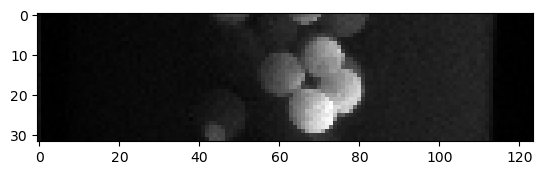

In [32]:
import matplotlib.pyplot as plt
plt.imshow(data[21,20,:,:], cmap='gray')  # 'cmap' defines the color map, 'gray' for grayscale
#plt.plot(xrf_data[:,0,16,60])  # Plot a line at each location specified in a
plt.show()

In [39]:

P_folder = './data/P_array/sample_64_64_64/detSpacing_0.4_dpts_5'
P_array_data = 'Intersecting_Length_64_64_64.h5'             
P_handle = h5py.File(os.path.join(P_folder, P_array_data), 'r')
P_array = P_handle['P_array']
print(P_array)


<HDF5 dataset "P_array": shape (5, 3, 34865152), type "<f4">


# Check initial guess

In [14]:
recon_path = '/home/beams/YJIANG/research/algorithm/XRF_tomography/XRF_tomography-main/3D/data/sample_8_size_64_test_recon_YJ/'
f_initial_guess = 'initialized_grid_concentration';
with h5py.File(os.path.join(recon_path, f_initial_guess +'.h5'), "r") as s:
    X = s["sample/densities"][...].astype(np.float32)
    elements = s["sample/elements"][...]
print(elements[0].dtype)
print(X.shape)

|S2
(2, 64, 64, 64)


# Check 3D structures

In [9]:
import h5py
import numpy as np
import dxchange

|S2


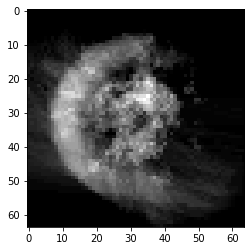

In [34]:
recon_path = '/home/beams/YJIANG/research/algorithm/XRF_tomography/XRF_tomography-main/3D/data/sample_8_size_64_test_recon_YJ/checkpoint'
f_recon_grid = '1_grid_concentration_2';
with h5py.File(os.path.join(recon_path, f_recon_grid +'.h5'), "r") as s:
    X = s["sample/densities"][...].astype(np.float32)
    elements = s["sample/elements"][...]
print(elements[0].dtype)
import matplotlib.pyplot as plt
plt.imshow(X[1,33], cmap='gray')  # 'cmap' defines the color map, 'gray' for grayscale
plt.show()

In [19]:
print(X[1,33])

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.0009844  0.00097601 0.00094836]]


In [13]:
dxchange.write_tiff(X_cpu[0], os.path.join(recon_path, f_recon_grid), dtype='float32', overwrite=True)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import mplcursors

# Generate example 3D image stack (replace this with your actual data)
stack_size = (10, 20, 30)
image_stack = np.random.random(stack_size)

# Function to update the 2D plot based on the slider value
def update(val):
    ax.cla()
    current_index = int(slider.val)
    ax.imshow(image_stack[current_index, :, :], cmap='viridis')
    ax.set_title(f'Slice {current_index}')
    plt.draw()

# Create initial 2D plot
fig, ax = plt.subplots()
initial_index = 0
ax.imshow(image_stack[initial_index, :, :], cmap='viridis')
ax.set_title(f'Slice {initial_index}')

# Create slider axes and slider
slider_ax = plt.axes([0.1, 0.02, 0.8, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(slider_ax, 'Slice', 0, stack_size[0] - 1, valinit=initial_index, valstep=1)

# Attach the slider update function to the slider
slider.on_changed(update)

# Enable interactive dragging of sliders in Jupyter Notebook
mplcursors.cursor(hover=True)

# Show the plot
plt.show()



ModuleNotFoundError: No module named 'mplcursors'

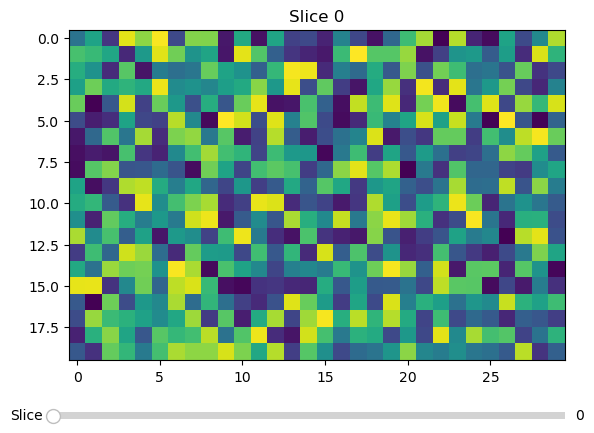

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D

# Generate example 3D image stack (replace this with your actual data)
stack_size = (10, 20, 30)
image_stack = np.random.random(stack_size)

# Function to update the 2D plot based on the slider value
def update(val):
    ax.cla()
    current_index = int(slider.val)
    ax.imshow(image_stack[current_index, :, :], cmap='viridis')
    ax.set_title(f'Slice {current_index}')
    plt.draw()

# Create initial 2D plot
fig, ax = plt.subplots()
initial_index = 0
ax.imshow(image_stack[initial_index, :, :], cmap='viridis')
ax.set_title(f'Slice {initial_index}')

# Create slider axes and slider
slider_ax = plt.axes([0.1, 0.02, 0.8, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(slider_ax, 'Slice', 0, stack_size[0] - 1, valinit=initial_index, valstep=1)

# Attach the slider update function to the slider
slider.on_changed(update)

# Show the plot
plt.show()


In [30]:
print(mask3D['200'].shape)

(231, 200, 53)


In [43]:
#### step 1: load parameters
Zr = io.imread(fn + 'Zr3D_00.tiff') # load true 3D object
Hf = io.imread(fn + 'Hf3D_00.tiff') # load true 3D object
img4D = FL.pre_treat(Zr, Hf) # combine 3D elemental objects to a 4D array
param = FL.load_param(fn + 'param_Zr_Hf.txt') # load experimental parameters (e.g. Xray energy, elements)
cs = FL.get_atten_coef(param['elem_type'], param['XEng'], param['em_E']) #fluorescence cross-section
elem_type = param['elem_type'] # list of elements
angle_list = np.arange(0, 180, 3) # projection angles
num_cpu = 8

XEng = 12.0 keV
pix size = 5.0e-06 cm
rho = 5.11 g/cm3
max thickness = 5.0 um
num of elem = 2
element type: ['Zr', 'Hf']
mass = [91.224, 178.49] g/mol
em_eng = [2.044, 7.899] keV
cs_em = [1.313, 14.97] cm2/g


In [44]:
print(cs)

{'elem_type': ['Zr', 'Hf'], 'Zr-x': 45.08905957690143, 'Zr-Zr': 769.4409363677769, 'Zr-Hf': 140.35202328041774, 'Hf-x': 226.866922224256, 'Hf-Zr': 3404.195471774754, 'Hf-Hf': 162.17129625527596}


In [40]:
#### step 2 (optional): generate perfect tomo reconstruction for reference
Zr_prj_perfect = FL.re_projection(Zr, angle_list) #generate perfect projections
# generate 3D reconstruction using perfect projections
Zr_rec_perfect = tomopy.recon(Zr_prj_perfect, angle_list/180*np.pi,
                Zr_prj_perfect.shape[2]/2-0.5,algorithm='mlem', num_iter=20)
Zr_rec_perfect = Zr_rec_perfect[:,::-1]
# save perfect projections and reconstructions
io.imsave(fn + f'ground_truth/prj_Zr_perfect.tiff', Zr_prj_perfect.astype(np.float32))
io.imsave(fn + f'ground_truth/rec_Zr_perfect.tiff', Zr_rec_perfect.astype(np.float32))

Hf_prj_perfect = FL.re_projection(Hf, angle_list)
Hf_rec_perfect = tomopy.recon(Hf_prj_perfect, angle_list/180*np.pi,
                Hf_prj_perfect.shape[2]/2-0.5,algorithm='mlem', num_iter=20)
Hf_rec_perfect = Hf_rec_perfect[:,::-1]
io.imsave(fn + f'ground_truth/prj_Hf_perfect.tiff', Hf_prj_perfect.astype(np.float32))
io.imsave(fn + f'ground_truth/rec_Hf_perfect.tiff', Hf_rec_perfect.astype(np.float32))


current angle: 0
current angle: 3
current angle: 6
current angle: 9
current angle: 12
current angle: 15
current angle: 18
current angle: 21
current angle: 24
current angle: 27
current angle: 30
current angle: 33
current angle: 36
current angle: 39
current angle: 42
current angle: 45
current angle: 48
current angle: 51
current angle: 54
current angle: 57
current angle: 60
current angle: 63
current angle: 66
current angle: 69
current angle: 72
current angle: 75
current angle: 78
current angle: 81
current angle: 84
current angle: 87
current angle: 90
current angle: 93
current angle: 96
current angle: 99
current angle: 102
current angle: 105
current angle: 108
current angle: 111
current angle: 114
current angle: 117
current angle: 120
current angle: 123
current angle: 126
current angle: 129
current angle: 132
current angle: 135
current angle: 138
current angle: 141
current angle: 144
current angle: 147
current angle: 150
current angle: 153
current angle: 156
current angle: 159
current angl

In [46]:
### SKIP
#### step 3:
# generate attenuated projection image at all angles
# will save attenuation and projection into file
# Be patient, this will take some time
fsave = fn+'Angle_prj_ground_truth'
num_cpu = 16
prj_atten = simu_atten_prj(mask3D, angle_list, img4D, param, cs, position_det='r', file_path=fsave, num_cpu=num_cpu)

# save projection image
for i in range(len(elem_type)):
    elem = elem_type[i]
    FL.write_projection('s', elem, prj_atten[elem], angle_list, file_path=fn+'simulated_proj')



simu attenuated projection at angle 0: 1/60
calculating attenuation for Zr
assembling slice using 16 CPUs


100%|███████████████████████████████████████████| 100/100 [00:35<00:00,  2.83it/s]

taking 35.9 sec
calculating attenuation for Hf
assembling slice using 16 CPUs



100%|███████████████████████████████████████████| 100/100 [00:30<00:00,  3.25it/s]


taking 31.2 sec
Zr_ref_prj_0000.tiff
Hf_ref_prj_0000.tiff

simu attenuated projection at angle 3: 2/60
calculating attenuation for Zr
assembling slice using 16 CPUs


...

taking 31.0 sec
Zr_ref_prj_0174.tiff
Hf_ref_prj_0174.tiff

simu attenuated projection at angle 177: 60/60
calculating attenuation for Zr
assembling slice using 16 CPUs


100%|███████████████████████████████████████████| 100/100 [00:30<00:00,  3.23it/s]

taking 31.5 sec
calculating attenuation for Hf
assembling slice using 16 CPUs



100%|███████████████████████████████████████████| 100/100 [00:30<00:00,  3.28it/s]


taking 31.0 sec
Zr_ref_prj_0177.tiff
Hf_ref_prj_0177.tiff


In [47]:
#### step 3:
# read simulated projection
f1 = h5py.File(fn+'simulated_proj/Zr_ref_prj_single_file.h5', 'r')
f2 = h5py.File(fn+'simulated_proj/Hf_ref_prj_single_file.h5', 'r')
Zr_prj = np.array(f1['dataset_1'])
Hf_prj = np.array(f2['dataset_1'])
f1.close()
f2.close()

In [50]:
print(Zr_prj.shape)
io.imsave(fn + f'simulated_proj/Hf_ref_prj_attenuated.tiff', Hf_prj.astype(np.float32))
io.imsave(fn + f'simulated_proj/Zr_ref_prj_attenuated.tiff', Zr_prj.astype(np.float32))


(60, 100, 100)


In [51]:
#### step 4:

# blind reconstruction using simulated-attenuated projection as what we got from experiment
# this serves as the starting point for the followinng correction
s = Zr_prj.shape
simu_prj = FL.pre_treat(Zr_prj, Hf_prj) # combine 3D elemental projections to a 4D array
simu_rec = simu_tomography(simu_prj, angle_list)
simu_rec = simu_rec[:, :, ::-1, :]

In [52]:
print(Zr_prj.shape)

(60, 100, 100)


In [ ]:

#### 1st iteration
# calculate the attenuation based on the current reconstruction

cal_and_save_atten_prj(mask3D, param, cs, simu_rec, angle_list, simu_prj, fsave=fn+'Angle_prj1', align_flag=0, num_cpu=num_cpu)

In [55]:
print(Zr>=0)

[[[ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  ...
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]]

 [[ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  ...
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]]

 [[ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  ...
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]]

 ...

 [[ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  [ True  True  True ...  True  True  True]
  ...
  [ True  True  True ...  True  True  Tr

In [6]:
sli = np.arange(100)
m = (Zr>0).astype(np.int16)
ref_tomo = np.ones(Zr.shape) * m
# correction on Zr
Zr_cor1 = simu_absorption_correction_mpi(sli, elem_type[0], ref_tomo, angle_list=angle_list, file_path=fn+'Angle_prj1', iter_num=30)
io.imsave(fn+'Zr_cor_01.tiff', Zr_cor1.astype(np.float32))

# correction on Hf
Hf_cor1 = simu_absorption_correction_mpi(sli, elem_type[1], ref_tomo, angle_list=angle_list, file_path=fn+'Angle_prj1', iter_num=30)
io.imsave(fn+'Hf_cor_01.tiff', Hf_cor1.astype(np.float32))



  0%|                                                   | 0/100 [00:00<?, ?it/s]

iteration: 0
iteration: 0
iteration: 0
iteration: 0
iteration: 0
iteration: 1
iteration: 0
iteration: 1iteration: 1

iteration: 1
iteration: 1
iteration: 1iteration: 2

iteration: 2
iteration: 2
iteration: 2
iteration: 2
iteration: 3
iteration: 3
iteration: 2
iteration: 3
iteration: 0iteration: 3

iteration: 3
iteration: 4
iteration: 4
iteration: 4
iteration: 3
iteration: 4
iteration: 1iteration: 5

iteration: 4
iteration: 0
iteration: 5
iteration: 4
iteration: 5
iteration: 2
iteration: 5
iteration: 6
iteration: 5
iteration: 1
iteration: 6
iteration: 5
iteration: 3
iteration: 6
iteration: 6
iteration: 7
iteration: 6
iteration: 2
iteration: 7
iteration: 6
iteration: 4
iteration: 7
iteration: 7
iteration: 8
iteration: 7
iteration: 3
iteration: 8
iteration: 7
iteration: 5
iteration: 8
iteration: 9
iteration: 8
iteration: 4
iteration: 8
iteration: 9
iteration: 8
iteration: 6
iteration: 9
iteration: 9
iteration: 5
iteration: 10
iteration: 9
iteration: 9iteration: 10

iteration: 7
iteration:


  1%|▍                                        | 1/100 [00:56<1:33:02, 56.39s/it]

iteration: 29
iteration: 27
iteration: 27
iteration: 28
iteration: 28
iteration: 29
iteration: 29



  2%|▊                                          | 2/100 [00:58<39:49, 24.38s/it]

...

iteration: 20
iteration: 28
iteration: 21
iteration: 29
iteration: 22



 99%|█████████████████████████████████████████▌| 99/100 [12:37<00:06,  6.82s/it]

iteration: 23
iteration: 24
iteration: 25
iteration: 26
iteration: 27
iteration: 28
iteration: 29


100%|█████████████████████████████████████████| 100/100 [12:40<00:00,  7.60s/it]

take 760.5 sec


In [7]:

#### 2st iteration
m = (Zr>0).astype(np.int16)
ref_tomo = np.ones(Zr.shape) * m
Zr_cor1 = io.imread(fn+'Zr_cor_01.tiff')
Hf_cor1 = io.imread(fn+'Hf_cor_01.tiff')
simu_rec1 = FL.pre_treat(Zr_cor1, Hf_cor1)
cal_and_save_atten_prj(mask3D, param, cs, simu_rec1, angle_list, simu_prj, fsave=fn+'Angle_prj2', align_flag=0, num_cpu=num_cpu)
sli = np.arange(100)
Zr_cor2 = simu_absorption_correction_mpi(sli, elem_type[0], ref_tomo, angle_list=angle_list, file_path=fn+'Angle_prj2', iter_num=30)
io.imsave(fn+'Zr_cor_02.tiff', Zr_cor2.astype(np.float32))
Hf_cor2 = simu_absorption_correction_mpi(sli, elem_type[1], ref_tomo, angle_list=angle_list, file_path=fn+'Angle_prj2', iter_num=30)
io.imsave(fn+'Hf_cor_02.tiff', Hf_cor2.astype(np.float32))



calculate and save attenuation and projection at angle 0: 1/60
calculating attenuation for Zr
assembling slice using  8 CPUs


100%|█████████████████████████████████████████| 100/100 [01:01<00:00,  1.62it/s]

taking 62.1 sec
calculating attenuation for Hf
assembling slice using  8 CPUs



100%|█████████████████████████████████████████| 100/100 [01:01<00:00,  1.63it/s]


taking 61.7 sec
Zr_ref_prj_0000.tiff
Hf_ref_prj_0000.tiff

calculate and save attenuation and projection at angle 3: 2/60
calculating attenuation for Zr
assembling slice using  8 CPUs


...

iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 0
iteration: 4
iteration: 0
iteration: 1
iteration: 5
iteration: 1
iteration: 2
iteration: 6
iteration: 2
iteration: 3
iteration: 7
iteration: 3
iteration: 4
iteration: 8
iteration: 4
iteration: 5
iteration: 9
iteration: 5
iteration: 6
iteration: 10
iteration: 6
iteration: 0
iteration: 7
iteration: 11
iteration: 7
iteration: 1
iteration: 8
iteration: 12
iteration: 8
iteration: 2
iteration: 13
iteration: 9
iteration: 3
iteration: 9
iteration: 10
iteration: 14
iteration: 4
iteration: 10
iteration: 11
iteration: 15
iteration: 5
iteration: 11
iteration: 12
iteration: 16
iteration: 6
iteration: 12
iteration: 13
iteration: 17
iteration: 13
iteration: 7
iteration: 14
iteration: 18
iteration: 14
iteration: 8
iteration: 15
iteration: 19
iteration: 15
iteration: 16
iteration: 9
iteration: 20
iteration: 16
iteration: 17
iteration: 10
iteration: 21
iteration: 17
iteration: 11
iteration: 18
iteration: 22
iteration: 18
iteration: 19
iter


 97%|████████████████████████████████████████▋ | 97/100 [12:29<00:32, 10.75s/it]

iteration: 20
iteration: 27
iteration: 27
iteration: 21
iteration: 28
iteration: 28
iteration: 22
iteration: 29
iteration: 29
iteration: 23
iteration: 24
iteration: 25
iteration: 26
iteration: 27
iteration: 28
iteration: 29


100%|█████████████████████████████████████████| 100/100 [12:34<00:00,  7.55s/it]

take 754.7 sec


In [12]:
io.imsave(fn+'Zr_attenuated0.tiff', simu_rec[0,:,:,:].astype(np.float32))
io.imsave(fn+'Hf_attenuated0.tiff', simu_rec[1,:,:,:].astype(np.float32))


(2, 100, 100, 100)
